STEP 1 — Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


STEP 2 — Paths

In [ ]:
ORIGINAL_DATASET = "/content/drive/MyDrive/Pneumonia Balanced CT"
BASE_PATH = "/content/dataset"

STEP 3 — Create Folders

In [ ]:
import os, shutil, random

splits = ['train','val','test']
classes = ['Normal','Pneumonia']

for s in splits:
    for c in classes:
        os.makedirs(os.path.join(BASE_PATH,s,c), exist_ok=True)

STEP 4 — Split Dataset (70/15/15)

In [ ]:
def split_class(cls):
    imgs = os.listdir(os.path.join(ORIGINAL_DATASET,cls))
    random.seed(42)
    random.shuffle(imgs)

    n = len(imgs)
    t1 = int(0.7*n)
    t2 = int(0.85*n)

    for f in imgs[:t1]:
        shutil.copy(os.path.join(ORIGINAL_DATASET,cls,f),
                    os.path.join(BASE_PATH,'train',cls,f))
    for f in imgs[t1:t2]:
        shutil.copy(os.path.join(ORIGINAL_DATASET,cls,f),
                    os.path.join(BASE_PATH,'val',cls,f))
    for f in imgs[t2:]:
        shutil.copy(os.path.join(ORIGINAL_DATASET,cls,f),
                    os.path.join(BASE_PATH,'test',cls,f))

for c in classes:
    split_class(c)

print("✅ Dataset split done")

✅ Dataset split done


STEP 5 — Load Libraries

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

STEP 6 — GAN Parameters

In [ ]:
IMG_SIZE = 128
LATENT_DIM = 100
BATCH_SIZE = 16
LAMBDA = 10

STEP 7 — Load Pneumonia Images

In [ ]:
def load_images(path):
    imgs = []
    for img in os.listdir(path):
        im = cv2.imread(os.path.join(path,img))
        if im is not None:
            im = cv2.resize(im,(IMG_SIZE,IMG_SIZE))
            im = im/127.5 - 1
            imgs.append(im)
    return np.array(imgs).astype("float32")

pneumonia_imgs = load_images(BASE_PATH+"/train/Pneumonia")
print("Loaded:", pneumonia_imgs.shape)

Loaded: (1833, 128, 128, 3)


STEP 8 — Build WGAN-GP

In [ ]:
def build_generator():
    model = models.Sequential([
        layers.Input(shape=(LATENT_DIM,)),
        layers.Dense(256*16*16),
        layers.Reshape((16,16,256)),

        layers.Conv2DTranspose(128,4,2,'same'),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.Conv2DTranspose(64,4,2,'same'),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.Conv2DTranspose(3,4,2,'same',activation='tanh')
    ])
    return model

Critic

In [ ]:
def build_critic():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE,IMG_SIZE,3)),
        layers.Conv2D(64,4,2,'same'),
        layers.LeakyReLU(0.2),

        layers.Conv2D(128,4,2,'same'),
        layers.LeakyReLU(0.2),

        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

STEP 9 — Train WGAN

In [ ]:
generator = build_generator()
critic = build_critic()

g_opt = tf.keras.optimizers.Adam(1e-4,0.0,0.9)
c_opt = tf.keras.optimizers.Adam(1e-4,0.0,0.9)

@tf.function
def train_wgan(real_imgs):

    for _ in range(5):
        noise = tf.random.normal([BATCH_SIZE,LATENT_DIM])

        with tf.GradientTape() as tape:
            fake = generator(noise, training=True)
            real_score = critic(real_imgs, training=True)
            fake_score = critic(fake, training=True)

            gp = tf.reduce_mean(tf.square(tf.sqrt(tf.reduce_sum(
                tf.square(tf.gradients(critic(real_imgs), real_imgs)[0]), axis=[1,2,3]))-1))

            c_loss = tf.reduce_mean(fake_score) - tf.reduce_mean(real_score) + LAMBDA*gp

        grads = tape.gradient(c_loss, critic.trainable_variables)
        c_opt.apply_gradients(zip(grads, critic.trainable_variables))

    noise = tf.random.normal([BATCH_SIZE,LATENT_DIM])
    with tf.GradientTape() as tape:
        fake = generator(noise, training=True)
        g_loss = -tf.reduce_mean(critic(fake, training=True))

    grads = tape.gradient(g_loss, generator.trainable_variables)
    g_opt.apply_gradients(zip(grads, generator.trainable_variables))

dataset = tf.data.Dataset.from_tensor_slices(pneumonia_imgs)\
                         .shuffle(1000)\
                         .batch(BATCH_SIZE, drop_remainder=True)

for epoch in range(30):
    for batch in dataset:
        train_wgan(batch)
    print(f"WGAN Epoch {epoch+1}/30")

WGAN Epoch 1/30
WGAN Epoch 2/30
WGAN Epoch 3/30
WGAN Epoch 4/30
WGAN Epoch 5/30
WGAN Epoch 6/30
WGAN Epoch 7/30
WGAN Epoch 8/30
WGAN Epoch 9/30
WGAN Epoch 10/30
WGAN Epoch 11/30
WGAN Epoch 12/30
WGAN Epoch 13/30
WGAN Epoch 14/30
WGAN Epoch 15/30
WGAN Epoch 16/30
WGAN Epoch 17/30
WGAN Epoch 18/30
WGAN Epoch 19/30
WGAN Epoch 20/30
WGAN Epoch 21/30
WGAN Epoch 22/30
WGAN Epoch 23/30
WGAN Epoch 24/30
WGAN Epoch 25/30
WGAN Epoch 26/30
WGAN Epoch 27/30
WGAN Epoch 28/30
WGAN Epoch 29/30
WGAN Epoch 30/30


STEP 10 — Generate GAN Images

In [ ]:
import math

REAL = len(os.listdir(BASE_PATH+"/train/Pneumonia"))
GEN = math.ceil(0.2 * REAL)

noise = tf.random.normal([GEN,LATENT_DIM])
fake_imgs = generator(noise, training=False)

for i in range(GEN):
    img = ((fake_imgs[i]+1)*127.5).numpy().astype("uint8")
    cv2.imwrite(f"{BASE_PATH}/train/Pneumonia/gan_{i}.png", img)

print("Generated:", GEN)

Generated: 367


STEP 11 — DenseNet121 Classifier

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(BASE_PATH+"/train",
                                           target_size=(224,224),
                                           batch_size=16,
                                           class_mode='binary')

val_data = val_gen.flow_from_directory(BASE_PATH+"/val",
                                       target_size=(224,224),
                                       batch_size=16,
                                       class_mode='binary',
                                       shuffle=False)

test_data = test_gen.flow_from_directory(BASE_PATH+"/test",
                                         target_size=(224,224),
                                         batch_size=16,
                                         class_mode='binary',
                                         shuffle=False)

Found 4032 images belonging to 2 classes.
Found 786 images belonging to 2 classes.
Found 786 images belonging to 2 classes.


STEP 12 — Build & Train Classifier

In [ ]:
base = DenseNet121(weights='imagenet',
                   include_top=False,
                   input_shape=(224,224,3))

for layer in base.layers:
    layer.trainable = False

x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(base.input, out)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(train_data,
          validation_data=val_data,
          epochs=15)

for layer in base.layers[-120:]:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(train_data,
          validation_data=val_data,
          epochs=8)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 115s 353ms/step - accuracy: 0.7140 - loss: 0.5769 - val_accuracy: 0.9491 - val_loss: 0.1844
Epoch 2/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 65s 257ms/step - accuracy: 0.9394 - loss: 0.1744 - val_accuracy: 0.9491 - val_loss: 0.1477
Epoch 3/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 63s 251ms/step - accuracy: 0.9601 - loss: 0.1252 - val_accuracy: 0.9746 - val_loss: 0.1032
Epoch 4/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 65s 258ms/step - accuracy: 0.9715 - loss: 0.0892 - val_accuracy: 0.9644 - val_loss: 0.1183
Epoch 5/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 65s 258ms/step - accuracy: 0.9724 - loss: 0.0814 - val_accuracy: 0.9733 - val_loss: 0.1007
Epoch 6/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 64s 255ms/step - accuracy: 0.9772 - loss: 0.0733 - val_accuracy: 0.9746 - val_loss: 0.0825
Epoch 7/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 64s 253ms/step - accuracy: 0.9756 - loss: 0.0653 - val_accuracy: 0.9720 - val_loss: 0.0905
Epoch 8/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 65s 258ms/step - accuracy: 0.9835 - loss: 

STEP 13 — Threshold Optimization

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

val_data.reset()
val_probs = model.predict(val_data).ravel()
val_true = val_data.classes

best_acc = 0
best_t = 0.5

for t in np.arange(0.30,0.60,0.01):
    preds = (val_probs > t).astype(int)
    acc = accuracy_score(val_true,preds)
    if acc > best_acc:
        best_acc = acc
        best_t = t

print("Best Threshold:", best_t)

50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 322ms/step
Best Threshold: 0.3


STEP 14 — Final Test Accuracy

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Reset generator
test_data.reset()

# Predict probabilities
y_prob = model.predict(test_data).ravel()

# Use best threshold from validation
y_pred = (y_prob > best_t).astype(int)

# True labels
y_true = test_data.classes

# Metrics
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))
print("AUC      :", roc_auc_score(y_true, y_prob))

50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 149ms/step
Accuracy : 0.989821882951654
Precision: 1.0
Recall   : 0.9796437659033079
F1 Score : 0.9897172236503856
AUC      : 1.0


STEP 15: CONFUSION MATRIX

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

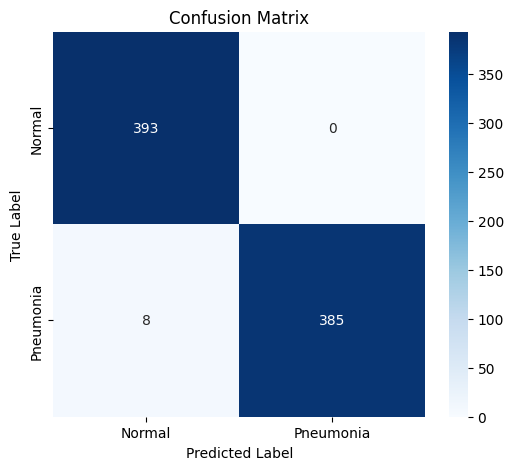

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Pneumonia"],
    yticklabels=["Normal", "Pneumonia"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Pneumonia"]
))

              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       393
   Pneumonia       1.00      0.98      0.99       393

    accuracy                           0.99       786
   macro avg       0.99      0.99      0.99       786
weighted avg       0.99      0.99      0.99       786



STEP 16: ACCURACY & LOSS CURVES

(For Two-Phase Training)

In [ ]:
model.history

In [ ]:
acc = model.history.history.get('accuracy', [])
val_acc = model.history.history.get('val_accuracy', [])

loss = model.history.history.get('loss', [])
val_loss = model.history.history.get('val_loss', [])

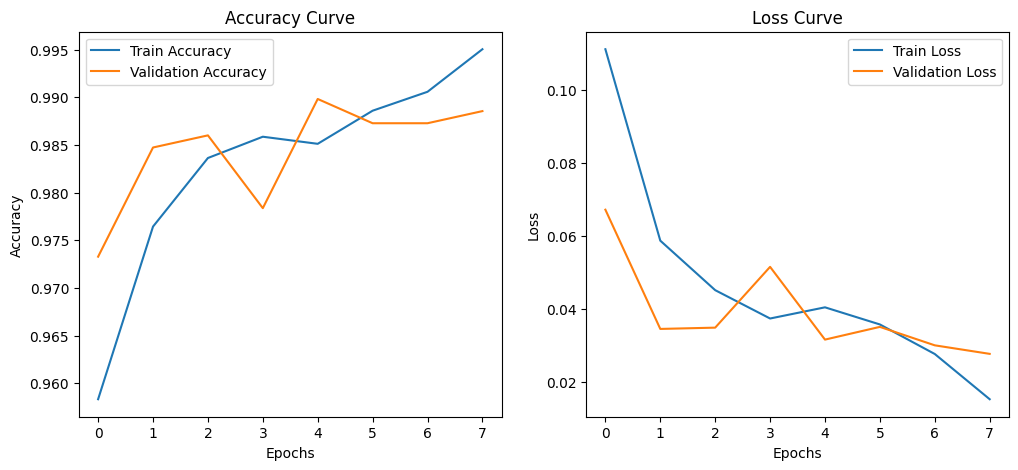

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.show()

STEP 19: ROC CURVE & AUC GRAPH

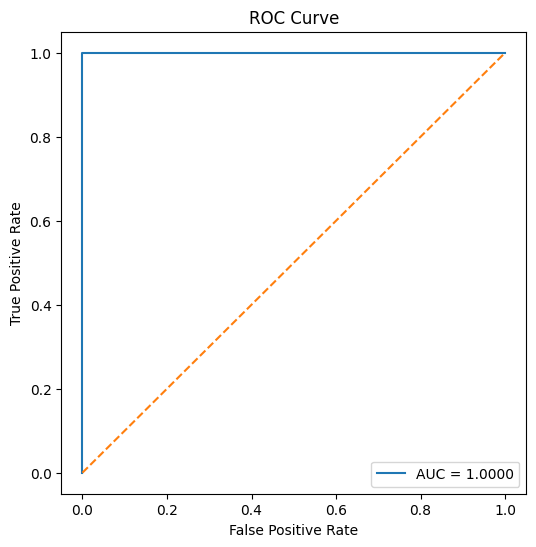

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()